# Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import os
os.chdir("./..")

import re
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

from pymorphy3 import MorphAnalyzer

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Loading dataset & Basic Cleaning

In [2]:
telegram_path = Path("data/telegram/telegram_data.csv")
tg_data = pd.read_csv(telegram_path)

In [3]:
tg_data.head()

,id,date,text
0,5002,2022-02-24 00:02:34+00:00,⚡️**Совбез ООН проведёт экстренное заседание п...
1,5003,2022-02-24 02:59:41+00:00,Путин прямо сейчас заявил о начале проведения ...
2,5004,2022-02-24 03:00:29+00:00,❗️**Военная операция в Донбассе начинается — з...
3,5005,2022-02-24 03:06:12+00:00,"‼️**Вся линия фронта, очень громко. Бьют из Гр..."
4,5006,2022-02-24 03:07:04+00:00,В аэропорту Жуляны не регестрируют пассажиров ...


# EDA

In [4]:
tg_data.shape

(385114, 3)

In [5]:
tg_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 385114 entries, 0 to 385113
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   id      385114 non-null  int64
 1   date    385114 non-null  str  
 2   text    357065 non-null  str  
dtypes: int64(1), str(2)
memory usage: 116.0 MB


# Data Cleaning  
At this stage we:
- convert the date column to datetime
- remove rows with missing values
- remove duplicate messages
- create additional time features

In [6]:
tg_data['date'] = pd.to_datetime(tg_data['date'], errors='coerce', utc=True)

tg_data = tg_data.dropna(subset=['date'])
tg_data['date'] = tg_data['date'].dt.tz_convert('Europe/Kiev')

tg_data = tg_data.dropna(subset=['text'])
tg_data = tg_data.drop_duplicates(subset=['text', 'date'])

In [7]:
tg_data.isna().sum()

id      0
date    0
text    0
dtype: int64

No critical missing values remain in the dataset

In [8]:
tg_data['hour'] = tg_data['date'].dt.hour
tg_data['day_of_week'] = tg_data['date'].dt.day_name()
tg_data['month_year'] = tg_data['date'].dt.to_period('M')
print(f"Кількість рядків: {tg_data.shape[0]}")

Кількість рядків: 357062


In [9]:
tg_data.head()

,id,date,text,hour,day_of_week,month_year
0,5002,2022-02-24 02:02:34+02:00,⚡️**Совбез ООН проведёт экстренное заседание п...,2,Thursday,2022-02
1,5003,2022-02-24 04:59:41+02:00,Путин прямо сейчас заявил о начале проведения ...,4,Thursday,2022-02
2,5004,2022-02-24 05:00:29+02:00,❗️**Военная операция в Донбассе начинается — з...,5,Thursday,2022-02
3,5005,2022-02-24 05:06:12+02:00,"‼️**Вся линия фронта, очень громко. Бьют из Гр...",5,Thursday,2022-02
4,5006,2022-02-24 05:07:04+02:00,В аэропорту Жуляны не регестрируют пассажиров ...,5,Thursday,2022-02


# 2. TIME-BASED ANALYSIS: Publishing Activity Heatmap  
Це покаже, в які дні тижня та години найчастіше пишуть в ТГ

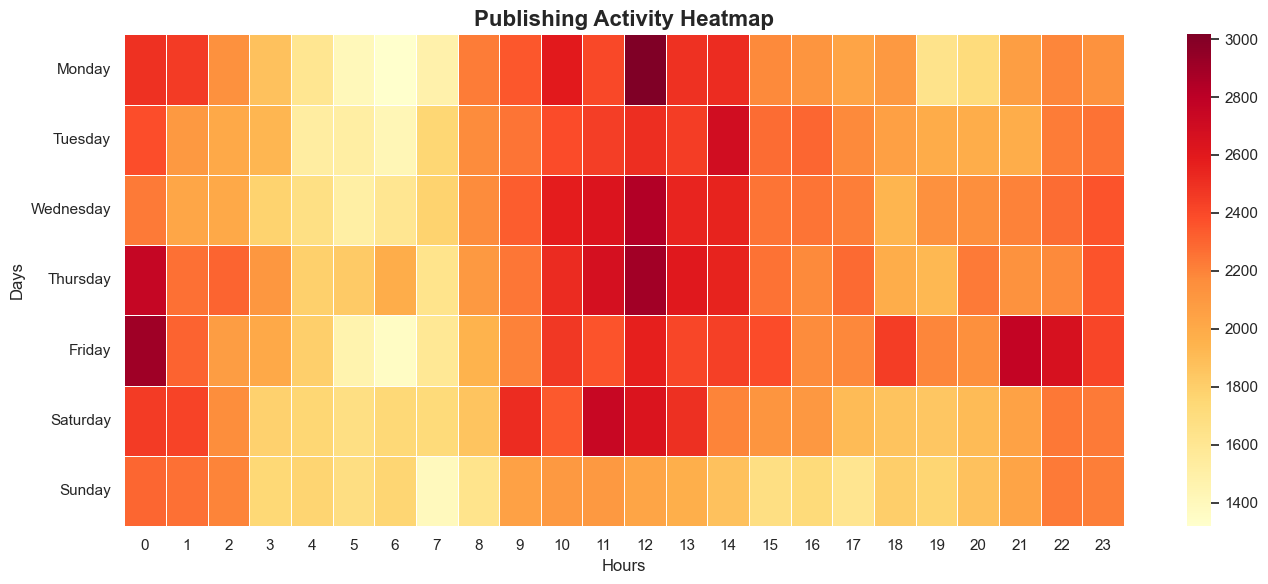

In [10]:
activity_matrix = tg_data.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
activity_matrix = activity_matrix.reindex(days_order)

plt.figure(figsize=(14, 6))
sns.heatmap(activity_matrix, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title("Publishing Activity Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("Hours")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

# Text Length Analysis  
Telegram message length distribution

We analyze the distribution of message lengths to understand
typical structure of Telegram alerts.

In [11]:
tg_data['text_length'] = tg_data['text'].astype(str).apply(len)

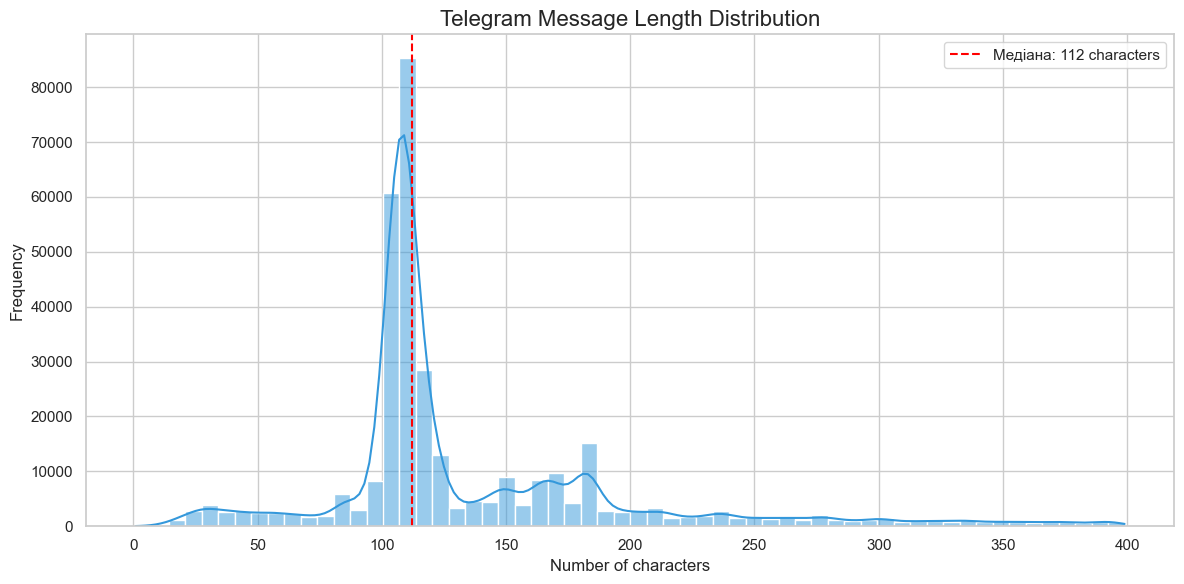

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(data=tg_data[tg_data['text_length'] < 400], x='text_length', bins=60, color='#3498db', kde=True)


median_len = tg_data['text_length'].median()
plt.axvline(median_len, color='red', linestyle='--', label=f'Медіана: {median_len:.0f} characters')

plt.title("Telegram Message Length Distribution", fontsize=16)
plt.xlabel("Number of characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Text preprocessing

We clean Telegram texts by:
- removing links
- removing mentions and hashtags
- removing punctuation
- removing stopwords

This step prepares the data for NLP analysis.

In [13]:
stop_words = {
    'і', 'в', 'на', 'з', 'що', 'як', 'до', 'та', 'це', 'за', 'по', 'про', 'від',
    'для', 'а', 'ми', 'вони', 'є', 'чи', 'або', 'але', 'тут', 'там', 'у',
    'и', 'с', 'что', 'как', 'к', 'это', 'о', 'от', 'які', 'який', 'все', 'цього', 'буде', 'вже',
    'так', "також", "типу", "нас", "нам",
    'слідкуйте', 'подальшими', 'повідомленнями',
    'новину', 'надіслати', 'підписатися',
    'зверніть', 'увагу', 'район', 'область', 'територіальна', 'громада', 'м_нікополь_та_нікопольська_територіальна_громада',
    'підписка', 'канал', 'адмін', 'джерело', 'посилання', 'наслідки'
}

In [14]:
morph = MorphAnalyzer(lang="uk")

def clean_text(text):
    text = str(text).lower() 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) 
    text = re.sub(r'\@\w+|\#', '', text) 
    text = re.sub(r'[^\w\s]', '', text) 
    text = text.replace('_', ' ')
    text = re.sub(r'\d+', '', text) 
    words = morph.parse(text)[0]
    words = words.normal_form
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

In [15]:
tg_data['clean_text'] = tg_data['text'].apply(clean_text)

In [16]:
tg_data.clean_text.head()

0    совбез оон проведёт экстренное заседание украи...
1    путин прямо сейчас заявил начале проведения сп...
2    военная операция донбассе начинается заявление...
3    вся линия фронта очень громко бьют градов без ...
4    аэропорту жуляны регестрируют пассажиров утрен...
Name: clean_text, dtype: str

# Threat keyword detection

We detect messages containing keywords related to air threats.

In [17]:
threat_keywords = ['пуск', 'виліт', 'баліст', 'мопед', 'шахед', 'ракет', 'укриття', 'увага', 'зліт', 'міг', 'кінжал', "бпла", "загроз"]

In [18]:
def has_threat(text):
    for word in threat_keywords:
        if word in str(text):
            return 1
    return 0

In [19]:
tg_data['has_threat_keyword'] = tg_data['clean_text'].apply(has_threat)

# TF-IDF Keyword Analysis

We compute the most important words in Telegram messages
using TF-IDF vectorization.

In [20]:
sample_texts = tg_data['clean_text'].dropna()

tfidf = TfidfVectorizer(max_features=20)
tfidf_matrix = tfidf.fit_transform(sample_texts)

In [21]:
tfidf_matrix.shape

(357062, 20)

In [22]:
tfidf.get_feature_names_out()

array(['артобстрілу', 'бпла', 'відбій', 'дніпропетровська', 'донецька',
       'загроза', 'загрози', 'запорізька', 'зараз', 'миколаївська',
       'нікополь', 'нікопольська', 'повітряна', 'полтавська', 'сумська',
       'триває', 'тривога', 'тривоги', 'укриття', 'харківська'],
      dtype=object)

In [23]:
# Рахуємо вагу кожного слова
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
words = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame({
    'Word': words,
    'TF-IDF Score': mean_tfidf
}).sort_values(by='TF-IDF Score', ascending=False)

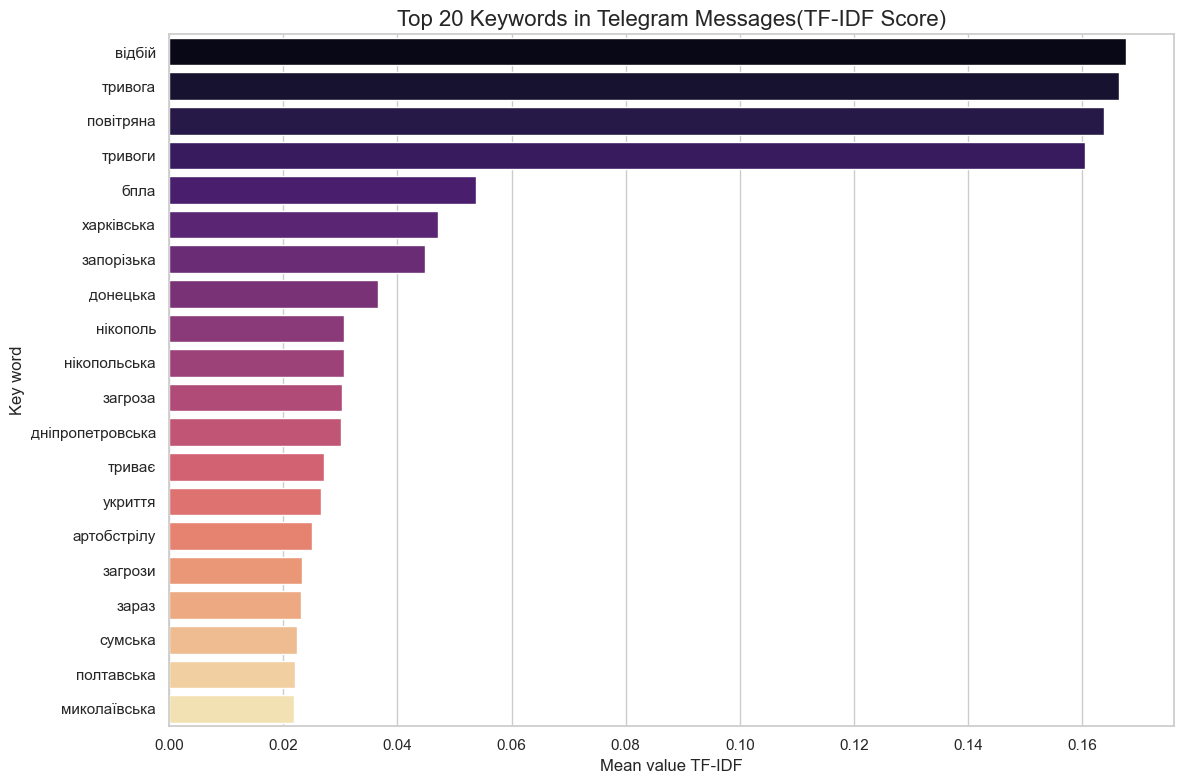

In [24]:
plt.figure(figsize=(12, 8))
sns.barplot(x='TF-IDF Score', y='Word', data=tfidf_df, palette='magma')
plt.title("Top 20 Keywords in Telegram Messages(TF-IDF Score)", fontsize=16)
plt.xlabel("Mean value TF-IDF", fontsize=12)
plt.ylabel("Key word", fontsize=12)
plt.tight_layout()
plt.show()

# Threat keyword trends

We track how often certain threat types appear over time.

In [25]:
# target_words = ['шахед', 'балістика', 'міг', 'кинджал']
target_words = threat_keywords

for word in target_words:
    tg_data[word] = tg_data['clean_text'].apply(lambda x: 1 if word in str(x) else 0)

In [26]:
trends_df = tg_data.set_index('date')[target_words].resample('ME').sum()

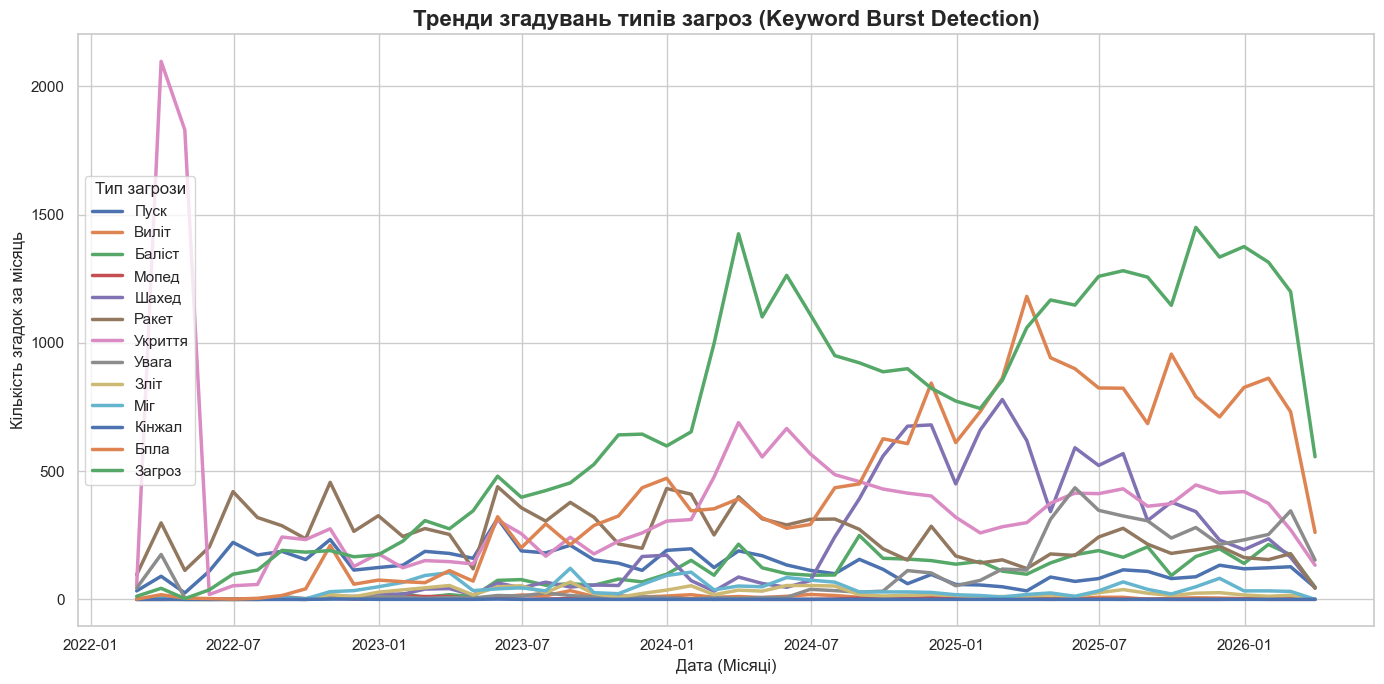

In [27]:
trends_df = tg_data.set_index('date')[target_words].resample('ME').sum()

plt.figure(figsize=(14, 7))
for word in target_words:
    plt.plot(trends_df.index, trends_df[word], linewidth=2.5, marker='', label=word.capitalize())

plt.title("Тренди згадувань типів загроз (Keyword Burst Detection)", fontsize=16, fontweight='bold')
plt.xlabel("Дата (Місяці)", fontsize=12)
plt.ylabel("Кількість згадок за місяць", fontsize=12)
plt.legend(title="Тип загрози")
plt.tight_layout()
plt.show()

# Message activity dynamics

We analyze how many Telegram messages appear over time.

In [28]:
weekly_counts = tg_data.resample('W', on='date').size()

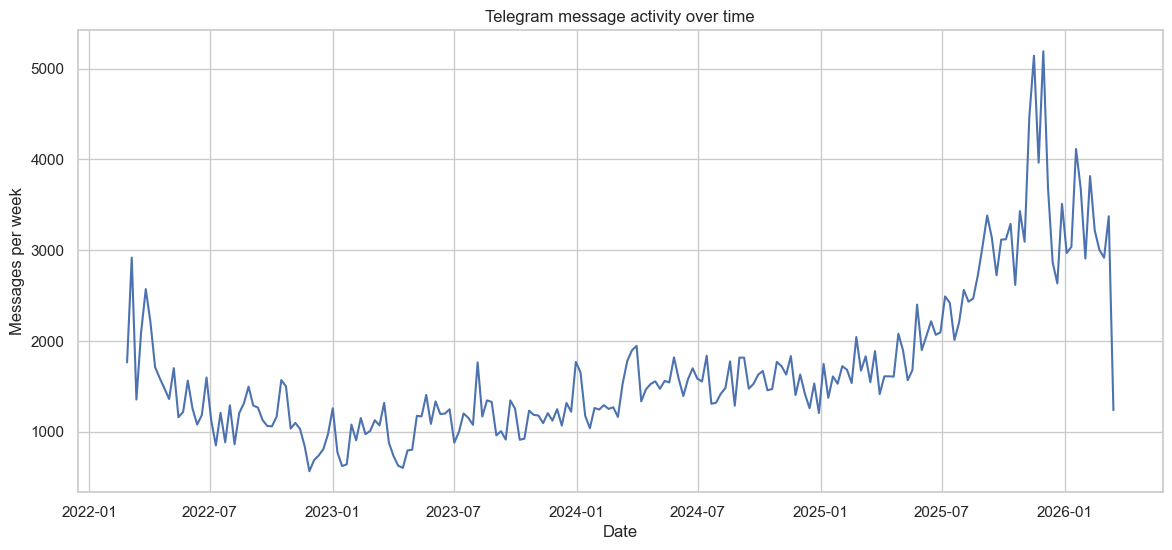

In [29]:
plt.figure(figsize=(14,6))

plt.plot(weekly_counts.index, weekly_counts.values)

plt.title("Telegram message activity over time")
plt.xlabel("Date")
plt.ylabel("Messages per week")

plt.show()

# Creating hourly dataset

For machine learning we aggregate Telegram messages by hour.

In [30]:
tg_data['date'] = pd.to_datetime(tg_data['date'], utc=True)

tg_data['hour_rounded'] = tg_data['date'].dt.floor('h').dt.tz_convert('Europe/Kiev')
tg_data['date'] = tg_data['date'].dt.tz_convert('Europe/Kiev')

In [31]:
hourly_tg = tg_data.groupby('hour_rounded').agg(
    messages_count=('text','count'),
    has_threat_sum=('has_threat_keyword','sum'),
    combined_text=('clean_text', lambda x:' '.join(x))
).reset_index()

full_range = pd.date_range(
    start=hourly_tg['hour_rounded'].min(),
    end=hourly_tg['hour_rounded'].max(),
    freq='h'
)

hourly_tg = (
    hourly_tg
    .set_index('hour_rounded')
    .reindex(full_range)
    .fillna({'messages_count':0,'has_threat_sum':0,'combined_text':''})
    .reset_index()
    .rename(columns={'index':'datetime'})
)

print(f"Отримано {hourly_tg.shape[0]} безперервних годин.")
display(hourly_tg.head(3))

Отримано 35441 безперервних годин.


,datetime,messages_count,has_threat_sum,combined_text
0,2022-02-24 02:00:00+02:00,1.0,0.0,совбез оон проведёт экстренное заседание украи...
1,2022-02-24 03:00:00+02:00,0.0,0.0,
2,2022-02-24 04:00:00+02:00,1.0,0.0,путин прямо сейчас заявил начале проведения сп...


# NLP feature generation
We extract most frequent words and bigrams using CountVectorizer.

In [32]:
vectorizer = CountVectorizer(max_features=15, ngram_range=(1,2))
text_vectors = vectorizer.fit_transform(hourly_tg['combined_text'])

In [33]:
cols = [f"nlp_{w.replace(' ','_')}" for w in vectorizer.get_feature_names_out()]
nlp_df = pd.DataFrame(text_vectors.toarray(), columns=cols)

hourly_tg = pd.concat([hourly_tg, nlp_df], axis=1)
hourly_tg = hourly_tg.drop(columns=['combined_text'])

# Feature engineering

Additional features:
- rolling message counts
- threat differences
- temporal features

In [34]:
hourly_tg['msg_count_last_3h'] = hourly_tg['messages_count'].rolling(3, min_periods=1).sum()
hourly_tg['msg_count_last_24h'] = hourly_tg['messages_count'].rolling(24, min_periods=1).sum()

hourly_tg['threat_diff_1h'] = hourly_tg['has_threat_sum'].diff().fillna(0)

hourly_tg['hour_of_day'] = hourly_tg['datetime'].dt.hour
hourly_tg['day_of_week'] = hourly_tg['datetime'].dt.dayofweek
hourly_tg['is_weekend'] = (hourly_tg['day_of_week'] >= 5).astype(int)

hourly_tg = hourly_tg.fillna(0)

# Save prepared dataset

We save the final dataset for further machine learning modeling.

In [35]:
display(hourly_tg.sample(5))

prepared_path = Path("data/telegram/telegram_hourly_features_v3.csv")
prepared_path.parent.mkdir(parents=True, exist_ok=True) 

hourly_tg.to_csv(prepared_path, index=False)

,datetime,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend
13624,2023-09-14 19:00:00+03:00,5.0,2.0,0,0,0,0,0,2,2,0,0,0,2,2,2,0,0,16.0,106.0,1.0,19,3,0
24681,2024-12-18 11:00:00+02:00,13.0,2.0,2,0,0,0,2,0,2,0,0,0,8,8,8,0,0,52.0,192.0,1.0,11,2,0
33573,2025-12-23 23:00:00+02:00,4.0,0.0,0,0,4,4,0,0,0,0,0,0,0,0,2,4,0,27.0,657.0,-2.0,23,1,0
32810,2025-11-22 04:00:00+02:00,3.0,0.0,0,0,2,2,0,0,0,0,0,0,0,0,0,2,0,29.0,565.0,0.0,4,5,1
25420,2025-01-18 06:00:00+02:00,9.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,62.0,231.0,-13.0,6,5,1
